# **Faizan Khan**

### Data Science Intern Oasis Infobyte internship july 2026

### Iris Flowers classification: iris flower has three species; Setosa,versicolor and verginica which differs according to their measurements.

## Step 1: Import Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

## Step 2: Importing Dataset

In [35]:
iris = load_iris()

In [36]:
x=iris.data  #features
y=iris.target #labels

In [37]:
#convert to a dataframe for easier viewing
df= pd.DataFrame(x,columns=iris.feature_names)
df['species']=y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 3: Describe Data

In [43]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Step 4: Plot Visualizations

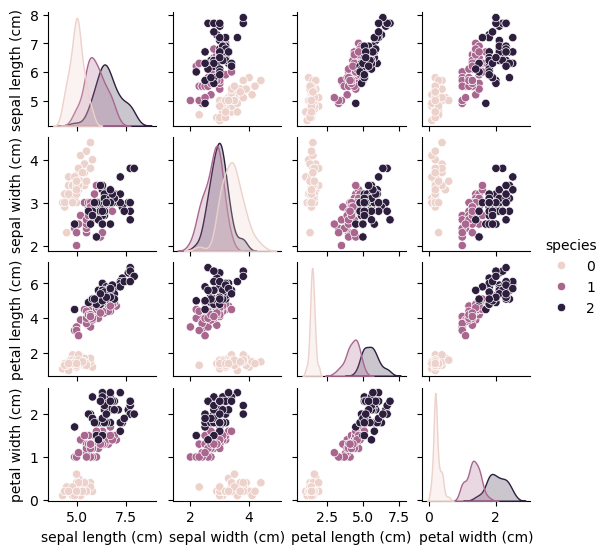

In [42]:
sns.pairplot(df,hue='species', height=1.4)
plt.show()

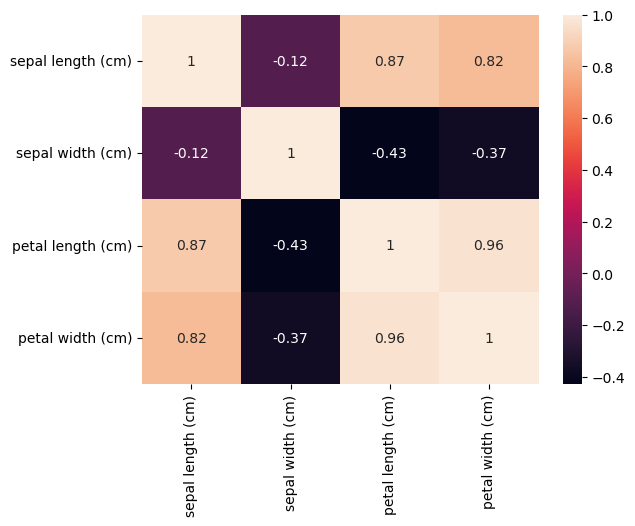

In [9]:
sns.heatmap(df.iloc[:,:-1].corr(),annot=True)
plt.show()

## Step 5: Train Test Split

In [10]:
#split dataset intp training and testing
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

## Step 6: Featuring Scaling

In [12]:
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

## Step 7: Train Model

In [13]:
#Train logistic regression model
model= LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

## step 8: Predict & Evaluate

In [14]:
y_pred= model.predict(x_test)

#model evaluate
print("Accurace:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accurace: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 9: Train Model using KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

## Step 10: Evaluate KNN model

In [16]:
knn_pred=knn.predict(x_test)
print("KNN Accuracy:",accuracy_score(y_test,knn_pred))

KNN Accuracy: 1.0


## Step 11: Train Decision Tree Model

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

## Step 12: Train Support Vector Machine(SVM)

In [18]:
from sklearn.svm import SVC
svm=SVC(kernel='linear')
svm.fit(x_train,y_train)

SVC(kernel='linear')

## Step 13: Compare Model Accuracies

In [20]:
models={
    "Logostic Regression":model,
    "KNN":knn,
    "Decision Tree":dt,
    "SVM":svm
}
for name,md1 in models.items():
    pred=md1.predict(x_test)
    print(name,"Accuracy:",accuracy_score(y_test,pred))

Logostic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0
SVM Accuracy: 0.9666666666666667


## Step 14: Predict on New Iris Flower Data

In [21]:
#Example flower measurements
new_flower=[[5.1,3.4,1.4,0.3]]
prediction=model.predict(scaler.transform(new_flower))
prediction

array([0])

## Step 15: Convert Prediction to Species name

In [26]:
species_map={
    0:"Versicolor",
    1:"Setosa",
    2:"Virginica"
}
species_map[prediction[0]]

'Versicolor'

## Step 16: Save Model

In [28]:
import joblib
joblib.dump(model,"iris_model.pk1")

['iris_model.pk1']

## Step 17: Load Saved data

In [29]:
loaded_model=joblib.load("iris_model.pk1")

## Step 18: Plot Confusion Matrix

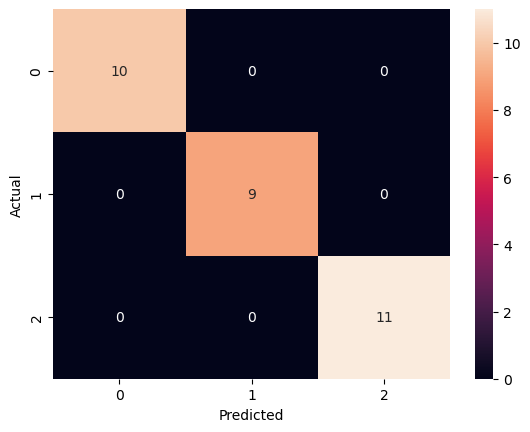

In [30]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Histogram

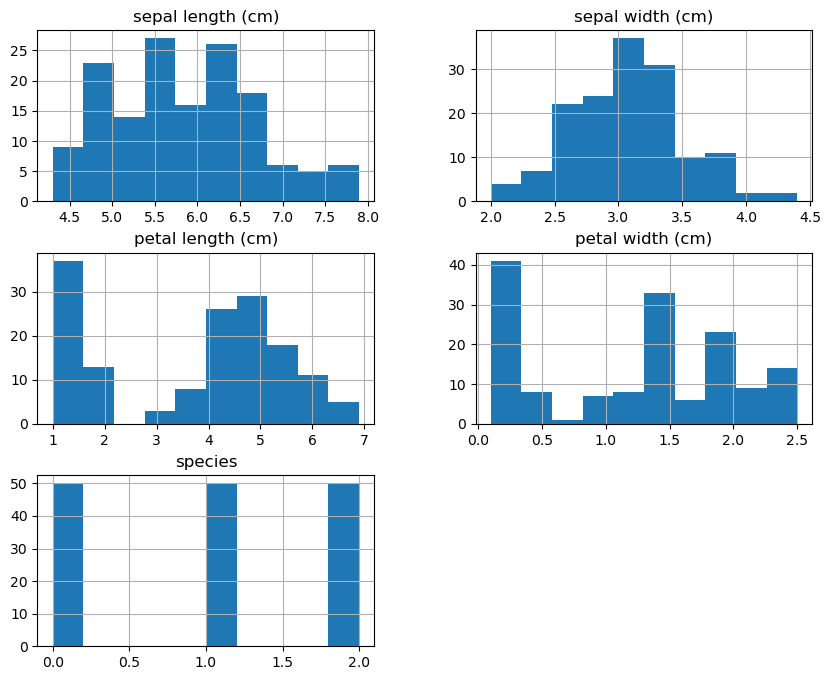

In [45]:
df.hist(figsize=(10,8))
plt.show()

## Boxplot

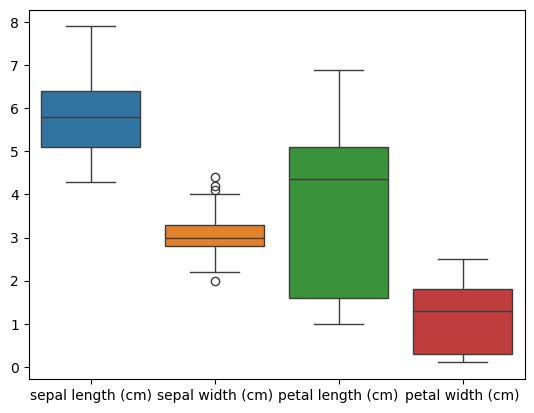

In [32]:
sns.boxplot(data=df.iloc[:,0:4])
plt.show()

## Show final Confusion Matrix

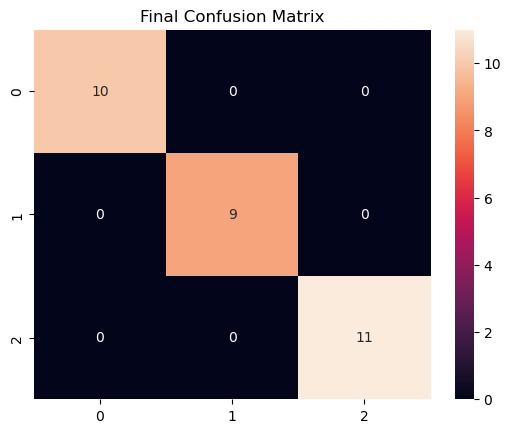

In [33]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True, fmt="d")
plt.title("Final Confusion Matrix")
plt.show()

## Thank You !